**Height / Weight로 Body Size 예측해보기**

# 1. 라이브러리 불러오기

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA

# 2. 데이터 불러오기

In [8]:
file_path = './최종데이터.xlsx'
df = pd.read_excel(file_path)
df.head()

,chest,waist,thigh,shoulder,arm,top,bottom,height,weight
0,89,72,53,44,57,44,98,178,60.9
1,102,84,60,44,56,40,94,170,71.8
2,101,86,59,45,56,40,94,167,71.7
3,105,79,58,47,59,42,98,173,74.8
4,100,83,60,46,63,42,105,183,78.9


# 3. 입력 / 출력 변수 설정
입력은 2개(weight, height)뿐이고, 출력은 신체 치수 7개라서 다중 출력 회귀 형태가 된다.

In [9]:
X_cols = ['weight', 'height']
Y_cols = ['chest','waist','thigh','shoulder','arm','top','bottom']

X = df[X_cols].values
Y = df[Y_cols].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# 4. 선형으로 봐도 되는지 먼저 확인

트리모델을 써야 하나 고민했는데, 일단 height/weight와 신체 치수 관계가 직선에 가까운지부터 확인해봤다

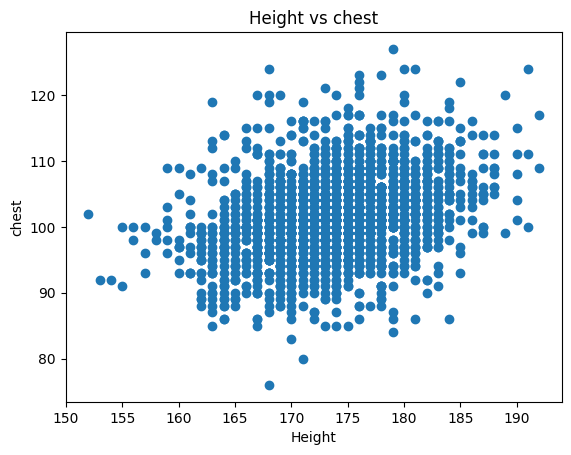

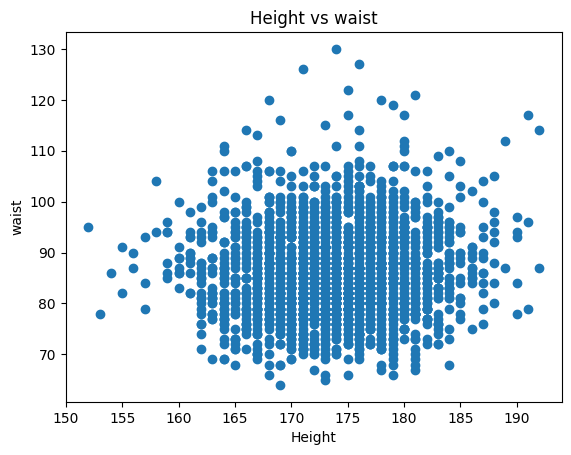

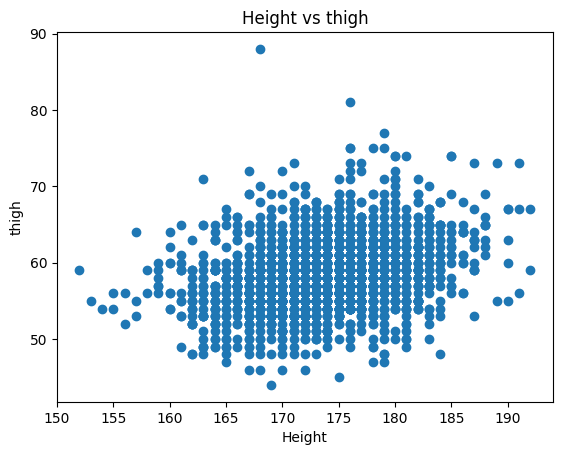

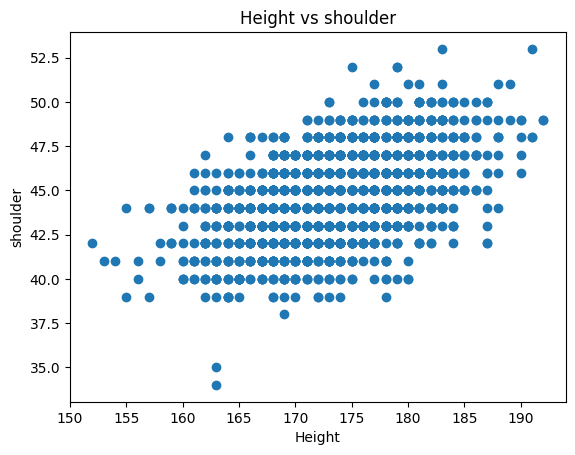

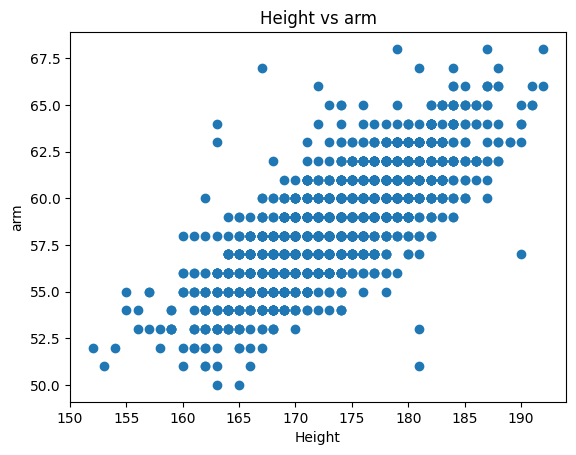

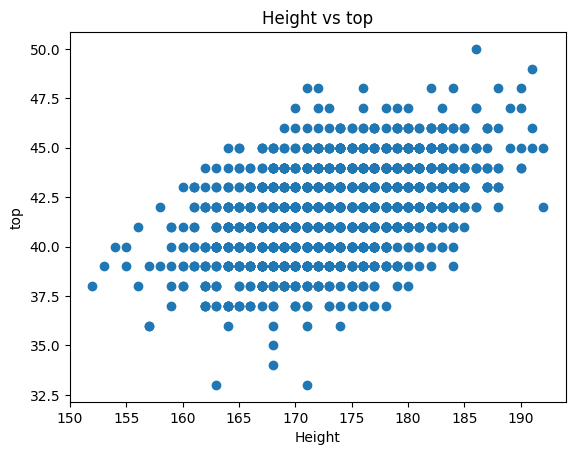

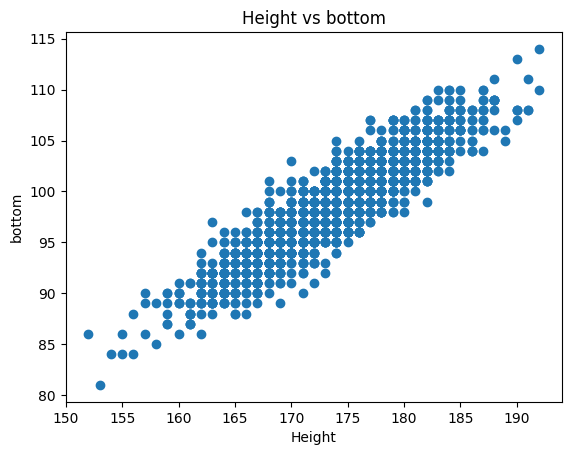

In [10]:
for col in Y_cols:
    plt.figure()
    plt.scatter(df['height'], df[col])
    plt.title(f'Height vs {col}')
    plt.xlabel('Height')
    plt.ylabel(col)
    plt.show()

# 5. 공통 평가 함수

모델을 여러 개 써보기 때문에, 같은 기준으로 비교하기 위해 MAE, MSE, R²를 같이 본다.

In [11]:
def evaluate(Y_test, Y_pred, model_name):
    mae = mean_absolute_error(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    print(f"\n[{model_name}]")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R² : {r2:.4f}")

# 6. OLS 회귀

OLS는 각 신체 치수마다 따로 학습시켜야 해서 반복문으로 하나씩 모델을 만들었다.

In [19]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

ols_preds = []

for i, col in enumerate(Y_cols):
    model = sm.OLS(Y_train[:, i], X_train_sm).fit()
    pred = model.predict(X_test_sm)
    ols_preds.append(pred)

Y_pred_ols = np.column_stack(ols_preds)
evaluate(Y_test, Y_pred_ols, "OLS Regression")


[OLS Regression]
MAE: 1.9264
MSE: 6.7767
R² : 0.6084


In [20]:
ols_models = []

for i in range(len(Y_cols)):
    model = sm.OLS(Y_train[:, i], X_train_sm).fit()
    ols_models.append(model)

# 7. Polynomial Regression

혹시 완전 선형은 아닐 수도 있어서 2차 다항 회귀도 시도해봤다.

In [15]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_preds = []

for i in range(Y_train.shape[1]):
    model = sm.OLS(Y_train[:, i], X_train_poly).fit()
    pred = model.predict(X_test_poly)
    poly_preds.append(pred)

Y_pred_poly = np.column_stack(poly_preds)
evaluate(Y_test, Y_pred_poly, "Polynomial Regression")


[Polynomial Regression]
MAE: 1.9062
MSE: 6.6026
R² : 0.6130


# 9. OLS 계수(기울기) 확인

OLS를 쓴 이유 중 하나는 height나 weight가 얼마나 영향을 주는지 수치로 보고 싶었기 때문이다.

In [16]:
for i, col in enumerate(Y_cols):
    model = sm.OLS(Y_train[:, i], X_train_sm).fit()
    print(f"\n[OLS Coefficients for {col}]")
    print(model.params)


[OLS Coefficients for chest]
[82.11625755  0.53627749 -0.11729321]

[OLS Coefficients for waist]
[134.52686925   0.81972606  -0.63092001]

[OLS Coefficients for thigh]
[50.00612018  0.41188458 -0.12759992]

[OLS Coefficients for shoulder]
[13.89032915  0.05523817  0.15411933]

[OLS Coefficients for arm]
[-2.57026693  0.02450727  0.34220143]

[OLS Coefficients for top]
[15.70807037  0.02852758  0.13764262]

[OLS Coefficients for bottom]
[-2.51381563e+01 -1.31825001e-02  7.17925726e-01]


================================================================

OLS 계수를 확인해보니,
부위마다 height와 weight의 영향이 다르게 나타났다.

waist와 chest는 몸무게의 영향을 크게 받았고,
arm이나 shoulder는 키의 영향을 더 크게 받는 것으로 보였다.

단순 예측뿐 아니라,
신체 부위별로 어떤 변수가 더 관련이 있는지도 확인할 수 있었다.

# 10. MANOVA로 통계적 유의성 확인

여기서 사용한 MANOVA) 는 처음부터 알고 있던 기법은 아니다.

모델을 이것저것 시도해보던 중, ChatGPT가 추천해줘서 처음 알게 되었고, 찾아보니 다음과 같은 상황에서 사용하는 통계 기법이라는 것을 알게 되었다:

Y(종속변수)가 여러 개인 경우
X(독립변수)가 이 Y들 전체에 유의미한 영향을 주는지 한 번에 검정할 때

내 데이터 구조가 정확히 여기에 해당했다.

X: weight, height (2개)
Y: chest, waist, thigh, shoulder, arm, top, bottom (7개)

즉,

"키와 몸무게가 신체 치수 전체에 통계적으로 의미 있는 영향을 주는가?"

를 확인하기에 적절한 방법이라 판단해서 적용해봤다.

여기서 중요한 점은, MANOVA는 예측 모델이 아니라, 변수들의 통계적 유의성을 확인하는 방법이라는 것이다.

In [17]:
manova_df = df[X_cols + Y_cols]

maov = MANOVA.from_formula(
    'chest + waist + thigh + shoulder + arm + top + bottom ~ weight + height',
    data=manova_df
)

print(maov.mv_test())

                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
         Intercept        Value  Num DF   Den DF  F Value  Pr > F
-----------------------------------------------------------------
            Wilks' lambda 0.2423 7.0000 2011.0000 898.5693 0.0000
           Pillai's trace 0.7577 7.0000 2011.0000 898.5693 0.0000
   Hotelling-Lawley trace 3.1278 7.0000 2011.0000 898.5693 0.0000
      Roy's greatest root 3.1278 7.0000 2011.0000 898.5693 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
         weight          Value  Num DF   Den DF   F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda  0.0755 7.0000 2011.0000 3520.0536 0.0000
         Pillai's trace  0.924

MANOVA 결과를 통해,
weight와 height가 신체 치수 전체(chest, waist, thigh, shoulder, arm, top, bottom)에
통계적으로 매우 유의미한 영향을 준다는 것을 확인했다. (p-value ≈ 0)

즉, 단순히 예측이 되는 것을 넘어서,
키와 몸무게가 실제로 신체 치수와 강한 관련이 있다는 것을
통계적으로 확인할 수 있었다.

# 11. (선택) 사용자 입력으로 예측해보기

모델이 실제로 어떻게 쓰일 수 있는지도 간단히 테스트했다.

In [24]:
import pandas as pd

#user_weight = float(input("Enter weight: "))
#user_height = float(input("Enter height: "))

user_X = pd.DataFrame(
    [[user_weight, user_height]],
    columns=['weight', 'height']
)

user_X_sm = sm.add_constant(user_X, has_constant='add')

print("\nPredicted Body Sizes (OLS):")
for i, col in enumerate(Y_cols):
    pred = ols_models[i].predict(user_X_sm)
    print(f"{col}: {pred[0]:.2f}")


Predicted Body Sizes (OLS):
chest: 113.36
waist: 106.41
thigh: 67.70
shoulder: 45.03
arm: 57.25
top: 41.54
bottom: 94.22


마무리

여러 모델을 직접 돌려보면서, 이 데이터에는 어떤 접근이 더 맞는지 확인해본 과정이다.

선형/비선형/트리 모델 비교
오차 지표로 성능 판단
계수로 해석
MANOVA로 통계적 의미 확인

처음에는 감으로 시작했지만, 결과적으로 모델 선택 과정을 스스로 검증해본 실험이 되었다.